In [ ]:
from spicexplorer.optimization.orchestrator import Circuit_Optimizer_Orchestrator_with_SPICE, Optimizer_Type_Enum
from spicexplorer_core.logging.logger_setup import setup_loggers, setup_loggers_with_spicelib_suppression

from pathlib import Path

logger = setup_loggers_with_spicelib_suppression()
# logger = setup_loggers()

## Comparison to CORA.OpAmp
Paper available [here](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=11270673)

### Circuit Schematic: Folded-cascode
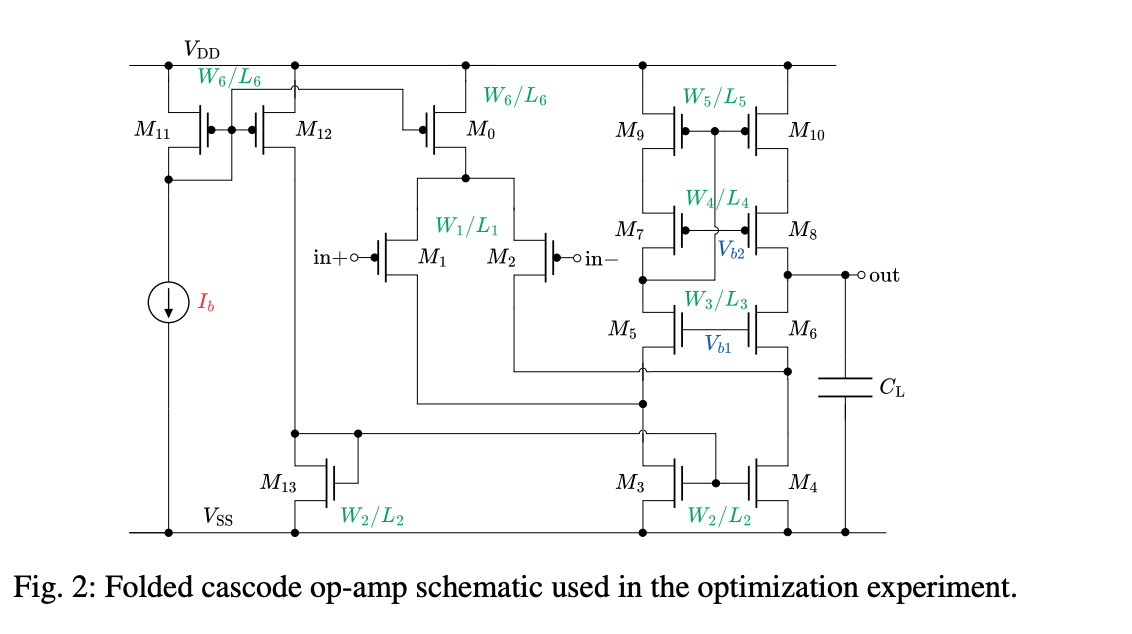

### Desgin Space Exploration Limits
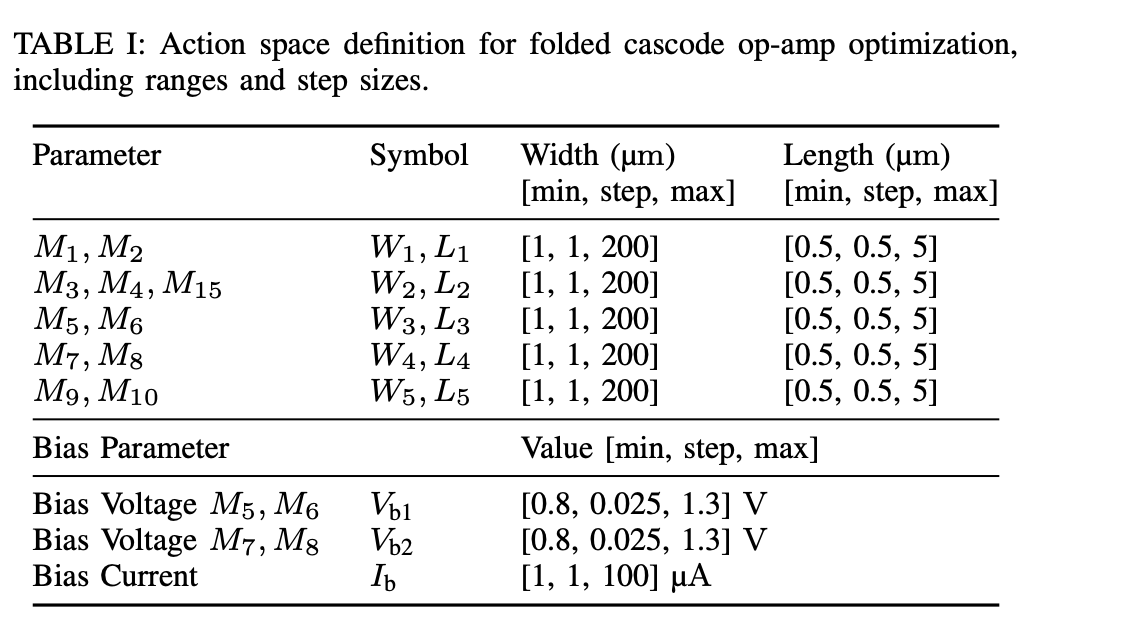

### Target Specs to Beat
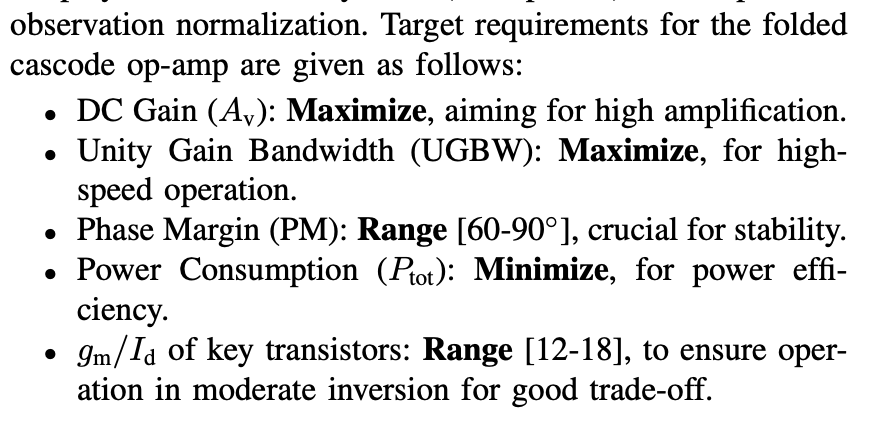
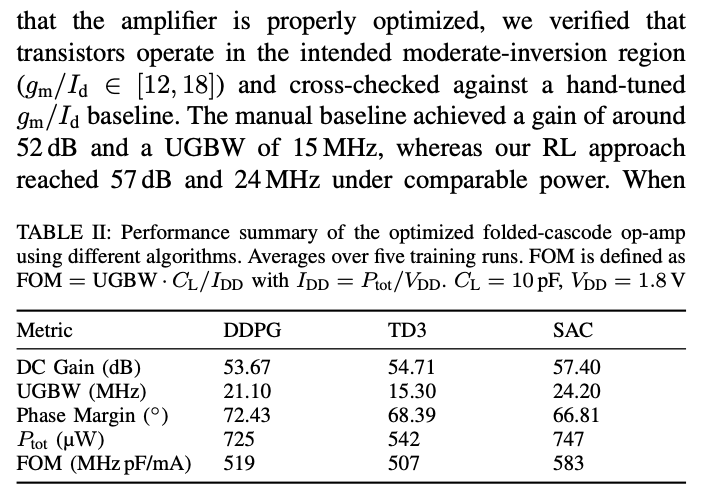

# Start of Optimization Code

In [ ]:
path_to_project_setup = Path("./project_setup.yaml")
optimizer_type = Optimizer_Type_Enum.NEVERGRAD_CONSTRAINT

In [ ]:
orchestrator = Circuit_Optimizer_Orchestrator_with_SPICE(
    project_setup_path=path_to_project_setup,
    optimizer_type=optimizer_type,
    verbose=True
)

In [ ]:
optimizer = orchestrator.get_optimizer()

In [ ]:
# orchestrator.run_sanity_on_spicelib_wrapper()

In [ ]:
optimizer.parameterize()

In [ ]:
optimizer.optimize()

## Viewing the Optimization Results

In [ ]:
optimizer.plot_score(show=True)

In [ ]:
optimizer.plot_optimization_trace(metric_x="ugf", metric_y="dcgain", show=True, save_path="./ugf_dcgain.html")
optimizer.plot_optimization_trace(metric_x="ugf", metric_y="pm", show=True, save_path="./ugf_pm.html")

In [ ]:
optimizer.save_checkpoint(name=f"{orchestrator.project_setup.optimizer_config.name}_{orchestrator.project_setup.optimizer_config.budget}")

## Cleanup

In [ ]:
# Uncomment the following line to clean up temporary files created during optimization
# optimizer.clean_up()